<a href="https://colab.research.google.com/github/Jyotishman2005/Mixed-Sound-Data-Segmentation/blob/main/my_notebook/KMeans_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('Mix.csv')
df.head(10)

,Gender,Heart Sound Type,Lung Sound Type,Location,Heart Sound ID,Lung Sound ID,Mixed Sound ID
0,F,Late Systolic Murmur,Rhonchi,LUSB,H0001,L0001,M0001
1,F,S3,Normal,RLA,H0002,L0002,M0002
2,M,Atrial Fibrillation,Normal,LMA,H0003,L0003,M0003
3,F,S3,Coarse Crackles,Apex,H0004,L0004,M0004
4,M,AV Block,Fine Crackles,RUSB,H0005,L0005,M0005
5,F,S3,Pleural Rub,RC,H0006,L0006,M0006
6,M,Tachycardia,Pleural Rub,Apex,H0007,L0007,M0007
7,F,Early Systolic Murmur,Pleural Rub,LMA,H0008,L0008,M0008
8,M,Mid Systolic Murmur,Wheezing,LUA,H0009,L0009,M0009
9,F,Early Systolic Murmur,Coarse Crackles,LUA,H0010,L0010,M0010


In [3]:
df2 = pd.read_csv('HS.csv')
df2.head(10)

,Gender,Heart Sound Type,Location,Heart Sound ID
0,F,Normal,RC,F_N_RC
1,F,Normal,LC,F_N_LC
2,M,Normal,RUSB,M_N_RUSB
3,F,Normal,LUSB,F_N_LUSB
4,F,Normal,LLSB,F_N_LLSB
5,F,Normal,Apex,F_N_A
6,M,Late Diastolic Murmur,LC,M_LDM_LC
7,M,Mid Systolic Murmur,Apex,M_MSM_A
8,F,Normal,RUSB,F_N_RUSB
9,F,Mid Systolic Murmur,Apex,F_MSM_A


In [4]:
df3 = pd.read_csv('LS.csv')
df3.head(10)

,Gender,Lung Sound Type,Location,Lung Sound ID
0,M,Normal,RUA,M_N_RUA
1,F,Normal,LUA,F_N_LUA
2,F,Normal,RMA,F_N_RMA
3,F,Normal,LMA,F_N_LMA
4,M,Normal,RLA,M_N_RLA
5,M,Normal,LLA,M_N_LLA
6,M,Pleural Rub,RMA,M_PR_RMA
7,M,Pleural Rub,LUA,M_PR_LUA
8,F,Rhonchi,LUA,F_R_LUA
9,M,Wheezing,LUA,M_W_LUA


In [5]:
print("DataFrame df info:")
df.info()
print("\nMissing values in df:")
print(df.isnull().sum())

print("\nDataFrame df2 info:")
df2.info()
print("\nMissing values in df2:")
print(df2.isnull().sum())

print("\nDataFrame df3 info:")
df3.info()
print("\nMissing values in df3:")
print(df3.isnull().sum())

DataFrame df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Gender            145 non-null    object
 1   Heart Sound Type  145 non-null    object
 2   Lung Sound Type   145 non-null    object
 3   Location          145 non-null    object
 4   Heart Sound ID    145 non-null    object
 5   Lung Sound ID     145 non-null    object
 6   Mixed Sound ID    145 non-null    object
dtypes: object(7)
memory usage: 8.1+ KB

Missing values in df:
Gender              0
Heart Sound Type    0
Lung Sound Type     0
Location            0
Heart Sound ID      0
Lung Sound ID       0
Mixed Sound ID      0
dtype: int64

DataFrame df2 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Gender       

In [6]:
#categorical ftures
categorical_cols = ['Gender', 'Heart Sound Type', 'Lung Sound Type', 'Location']


id_cols = ['Heart Sound ID', 'Lung Sound ID', 'Mixed Sound ID']

# to not modify the actual dataset
df_encoded = df.copy()

df_encoded = df_encoded.drop(columns=id_cols)

#one-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=False)

print("Shape of original df:", df.shape)
print("Shape of df after encoding and dropping IDs:", df_encoded.shape)
print("\nFirst 5 rows of the encoded DataFrame:")
display(df_encoded.head(10))


Shape of original df: (145, 7)
Shape of df after encoding and dropping IDs: (145, 30)

First 5 rows of the encoded DataFrame:


,Gender_F,Gender_M,Heart Sound Type_AV Block,Heart Sound Type_Atrial Fibrillation,Heart Sound Type_Early Systolic Murmur,Heart Sound Type_Late Diastolic Murmur,Heart Sound Type_Late Systolic Murmur,Heart Sound Type_Mid Systolic Murmur,Heart Sound Type_Normal,Heart Sound Type_S3,...,Location_LLA,Location_LLSB,Location_LMA,Location_LUA,Location_LUSB,Location_RC,Location_RLA,Location_RMA,Location_RUA,Location_RUSB
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,False,True,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
6,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,True,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
8,False,True,False,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
9,True,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_encoded)

# Convert the scaled array back to a DataFrame for easier inspection
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

print("Shape of scaled DataFrame:", df_scaled.shape)
print("\nFirst 5 rows of the scaled DataFrame:")
display(df_scaled.head(10))


Shape of scaled DataFrame: (145, 30)

First 5 rows of the scaled DataFrame:


,Gender_F,Gender_M,Heart Sound Type_AV Block,Heart Sound Type_Atrial Fibrillation,Heart Sound Type_Early Systolic Murmur,Heart Sound Type_Late Diastolic Murmur,Heart Sound Type_Late Systolic Murmur,Heart Sound Type_Mid Systolic Murmur,Heart Sound Type_Normal,Heart Sound Type_S3,...,Location_LLA,Location_LLSB,Location_LMA,Location_LUA,Location_LUSB,Location_RC,Location_RLA,Location_RMA,Location_RUA,Location_RUSB
0,0.993127,-0.993127,-0.313823,-0.339683,-0.313823,-0.313823,2.743977,-0.326910,-0.313823,-0.339683,...,-0.300376,-0.300376,-0.313823,-0.300376,3.329164,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823
1,0.993127,-0.993127,-0.313823,-0.339683,-0.313823,-0.313823,-0.364434,-0.326910,-0.313823,2.943920,...,-0.300376,-0.300376,-0.313823,-0.300376,-0.300376,-0.326910,3.329164,-0.286513,-0.257248,-0.313823
2,-1.006920,1.006920,-0.313823,2.943920,-0.313823,-0.313823,-0.364434,-0.326910,-0.313823,-0.339683,...,-0.300376,-0.300376,3.186510,-0.300376,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823
3,0.993127,-0.993127,-0.313823,-0.339683,-0.313823,-0.313823,-0.364434,-0.326910,-0.313823,2.943920,...,-0.300376,-0.300376,-0.313823,-0.300376,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823
4,-1.006920,1.006920,3.186510,-0.339683,-0.313823,-0.313823,-0.364434,-0.326910,-0.313823,-0.339683,...,-0.300376,-0.300376,-0.313823,-0.300376,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,3.186510
5,0.993127,-0.993127,-0.313823,-0.339683,-0.313823,-0.313823,-0.364434,-0.326910,-0.313823,2.943920,...,-0.300376,-0.300376,-0.313823,-0.300376,-0.300376,3.058945,-0.300376,-0.286513,-0.257248,-0.313823
6,-1.006920,1.006920,-0.313823,-0.339683,-0.313823,-0.313823,-0.364434,-0.326910,-0.313823,-0.339683,...,-0.300376,-0.300376,-0.313823,-0.300376,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823
7,0.993127,-0.993127,-0.313823,-0.339683,3.186510,-0.313823,-0.364434,-0.326910,-0.313823,-0.339683,...,-0.300376,-0.300376,3.186510,-0.300376,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823
8,-1.006920,1.006920,-0.313823,-0.339683,-0.313823,-0.313823,-0.364434,3.058945,-0.313823,-0.339683,...,-0.300376,-0.300376,-0.313823,3.329164,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823
9,0.993127,-0.993127,-0.313823,-0.339683,3.186510,-0.313823,-0.364434,-0.326910,-0.313823,-0.339683,...,-0.300376,-0.300376,-0.313823,3.329164,-0.300376,-0.326910,-0.300376,-0.286513,-0.257248,-0.313823


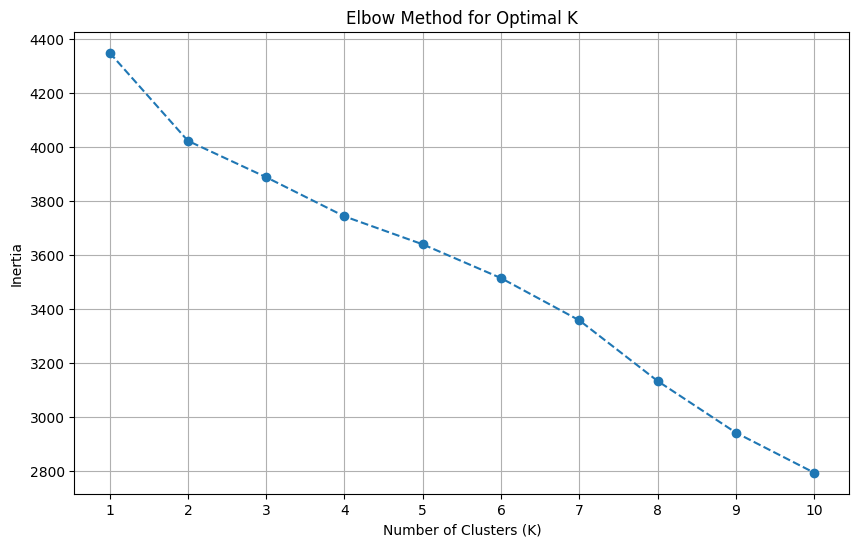

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print(f'KMeans applied with {n_clusters} clusters (based on the Elbow point at 2).')
display(df_encoded.head())

print('\nCluster Sizes:')
display(df_encoded['Cluster'].value_counts())

KMeans applied with 3 clusters (based on the Elbow point at 2).


,Gender_F,Gender_M,Heart Sound Type_AV Block,Heart Sound Type_Atrial Fibrillation,Heart Sound Type_Early Systolic Murmur,Heart Sound Type_Late Diastolic Murmur,Heart Sound Type_Late Systolic Murmur,Heart Sound Type_Mid Systolic Murmur,Heart Sound Type_Normal,Heart Sound Type_S3,...,Location_LLSB,Location_LMA,Location_LUA,Location_LUSB,Location_RC,Location_RLA,Location_RMA,Location_RUA,Location_RUSB,Cluster
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,1
1,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,1
2,False,True,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,2
3,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
4,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0



Cluster Sizes:


,count
Cluster,
2,64
1,56
0,25


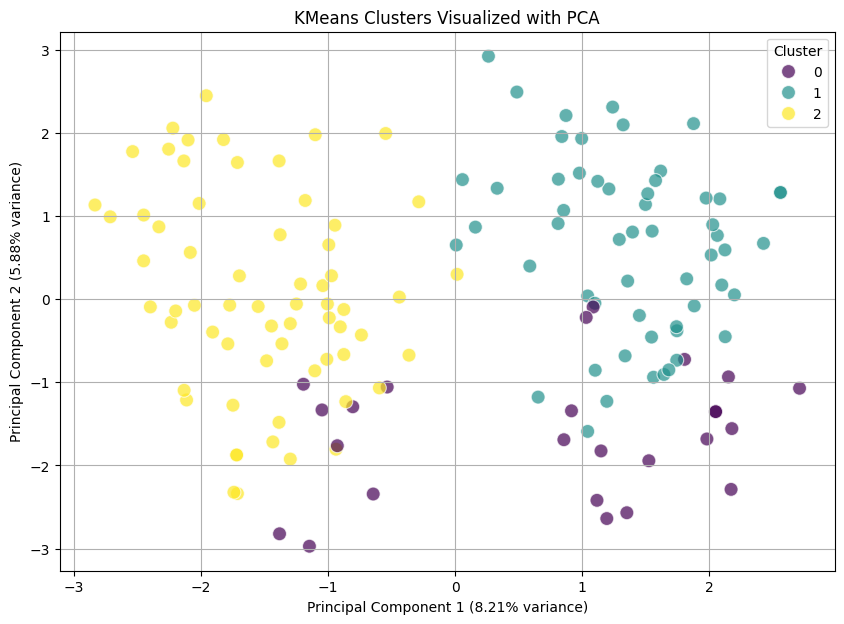

In [10]:
from sklearn.decomposition import PCA
import seaborn as sns

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

# Create a temporary DataFrame for plotting
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df_encoded['Cluster'].values

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_df, s=100, alpha=0.7)
plt.title('KMeans Clusters Visualized with PCA')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [11]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print(f'KMeans applied with {n_clusters} clusters (based on the Elbow point at 2).')
display(df_encoded.head())

print('\nCluster Sizes:')
display(df_encoded['Cluster'].value_counts())

KMeans applied with 2 clusters (based on the Elbow point at 2).


,Gender_F,Gender_M,Heart Sound Type_AV Block,Heart Sound Type_Atrial Fibrillation,Heart Sound Type_Early Systolic Murmur,Heart Sound Type_Late Diastolic Murmur,Heart Sound Type_Late Systolic Murmur,Heart Sound Type_Mid Systolic Murmur,Heart Sound Type_Normal,Heart Sound Type_S3,...,Location_LLSB,Location_LMA,Location_LUA,Location_LUSB,Location_RC,Location_RLA,Location_RMA,Location_RUA,Location_RUSB,Cluster
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,1
1,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,1
2,False,True,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,0
3,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
4,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0



Cluster Sizes:


,count
Cluster,
1,73
0,72


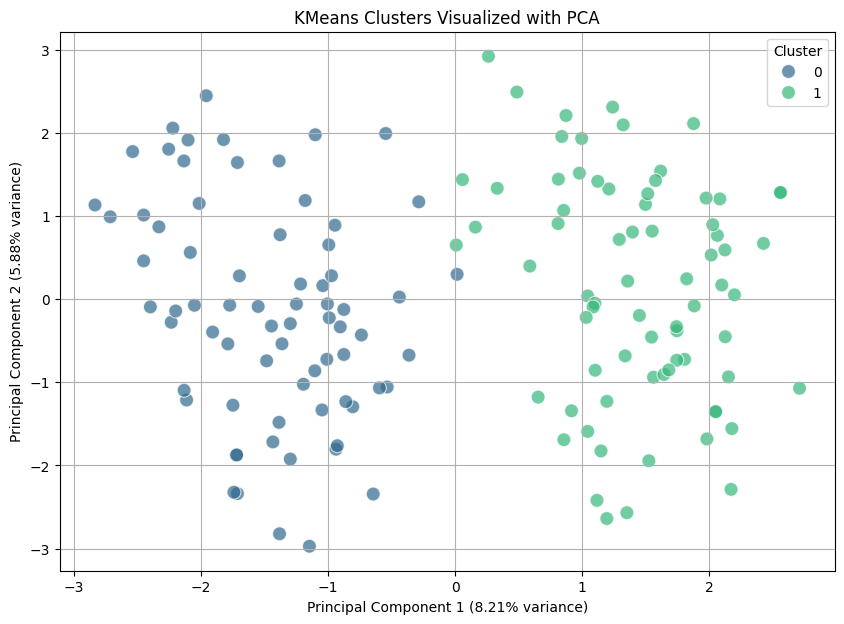

In [12]:
from sklearn.decomposition import PCA
import seaborn as sns

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

# Create a temporary DataFrame for plotting
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df_encoded['Cluster'].values

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_df, s=100, alpha=0.7)
plt.title('KMeans Clusters Visualized with PCA')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [13]:
from sklearn.cluster import KMeans
import pandas as pd

# Perform KMeans for K=2
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_k2 = kmeans_k2.fit_predict(df_scaled)

# Perform KMeans for K=3
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_k3 = kmeans_k3.fit_predict(df_scaled)

# Create a comparison DataFrame with original IDs and both cluster results
df_comparison = df.copy()
df_comparison['Cluster_K2'] = clusters_k2
df_comparison['Cluster_K3'] = clusters_k3

# Save to CSV files
df_comparison[['Mixed Sound ID', 'Cluster_K2']].to_csv('clusters_k2.csv', index=False)
df_comparison[['Mixed Sound ID', 'Cluster_K3']].to_csv('clusters_k3.csv', index=False)

print("CSV files 'clusters_k2.csv' and 'clusters_k3.csv' have been generated.")

# Compare clusters using a cross-tabulation
comparison_table = pd.crosstab(df_comparison['Cluster_K2'], df_comparison['Cluster_K3'])
print("\nSimilarity Comparison (K=2 vs K=3):")
display(comparison_table)

CSV files 'clusters_k2.csv' and 'clusters_k3.csv' have been generated.

Similarity Comparison (K=2 vs K=3):


Cluster_K3,0,1,2
Cluster_K2,,,
0,8,0,64
1,17,56,0
